In [1]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# Loading Data


In [2]:
# Load & prepare the data
def load_and_prepare_data():
    # Loading dataset
    dataset = pd.read_csv('Social_Network_Ads.csv')
    # Age and Salary
    X = dataset.iloc[:, [2, 3]].values  
    # Purchased
    y = dataset.iloc[:, 4].values       

    # Split the dataset
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

    # Scaling Feature 
    sc = StandardScaler()
    X_train = sc.fit_transform(X_train)
    X_test = sc.transform(X_test)

    return X_train, X_test, y_train, y_test, sc

def plot_decision_boundary(X, y, model, title):
    # Create mesh grid
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    XX, YY = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))

    # predictions
    Z = model.predict(np.c_[XX.ravel(), YY.ravel()])
    Z = Z.reshape(XX.shape)

    # Plot decision boundary
    plt.figure(figsize=(10, 8))
    plt.contourf(XX, YY, Z, alpha=0.4)
    plt.scatter(X[:, 0], X[:, 1], c=y, alpha=0.8)

    # Plot support vectors if available
    if hasattr(model, 'support_vectors_'):
        plt.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1],
                   s=100, linewidth=1, facecolors='none', edgecolors='k',
                   label='Support Vectors')

    plt.title(title)
    plt.xlabel('Age (Standardized)')
    plt.ylabel('Salary (Standardized)')
    plt.legend()
    plt.show()

def evaluate_model(model, X_test, y_test):
    # Make predictions
    y_pred = model.predict(X_test)

    # Calculate confusion matrix and accuracy
    CM = confusion_matrix(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)

    return CM, acc

def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

## 1

In [3]:
#1: Visualize the data
def visualize_raw_data(X, y):
    plt.figure(figsize=(10, 8))
    plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], c='red', label='No Purchase')
    plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], c='green', label='Purchase')
    plt.title('Social Network Ads Data Distribution')
    plt.xlabel('Age (Standardized)')
    plt.ylabel('Salary (Standardized)')
    plt.legend()
    plt.show()

## 2 & 3


In [4]:
#2 & 3: Linear SVM
def linear_svm_analysis(X_train, X_test, y_train, y_test):
    # Training linear SVM
    linear_svm = SVC(kernel='linear', random_state=42)
    linear_svm.fit(X_train, y_train)

    # Plot decision boundary with support vectors
    plot_decision_boundary(X_train, y_train, linear_svm, 'Linear SVM Decision Boundary')

    # Evaluating model
    CM, acc = evaluate_model(linear_svm, X_test, y_test)
    plot_confusion_matrix(CM, 'Linear SVM Confusion Matrix')

    return linear_svm, acc

## 4

In [5]:
#4: Different kernels
def kernel_svm_analysis(X_train, X_test, y_train, y_test):
    kernels = ['rbf', 'poly']
    results = {}

    for kernel in kernels:
        # Train SVM with different kernels
        svm = SVC(kernel=kernel, random_state=42)
        svm.fit(X_train, y_train)

        # Plot decision boundary
        plot_decision_boundary(X_train, y_train, svm, f'{kernel.upper()} Kernel SVM Decision Boundary')

        # Evaluate model
        cm, acc = evaluate_model(svm, X_test, y_test)
        plot_confusion_matrix(cm, f'{kernel.upper()} Kernel SVM Confusion Matrix')

        results[kernel] = acc

    return results

## 6

In [6]:

# 6: C parameter analysis
def c_parameter_analysis(X_train, X_test, y_train, y_test):
    C_values = [0.001, 0.01, 0.1, 1, 10, 100]
    accuracies = []

    for c in C_values:
        svm = SVC(kernel='linear', C=c, random_state=42)
        svm.fit(X_train, y_train)
        _, acc = evaluate_model(svm, X_test, y_test)
        accuracies.append(acc)

    plt.figure(figsize=(10, 6))
    plt.semilogx(C_values, accuracies, 'bo-')
    plt.xlabel('C Value (log scale)')
    plt.ylabel('Accuracy')
    plt.title('SVM Accuracy vs C Parameter')
    plt.grid(True)
    plt.show()

    return dict(zip(C_values, accuracies))

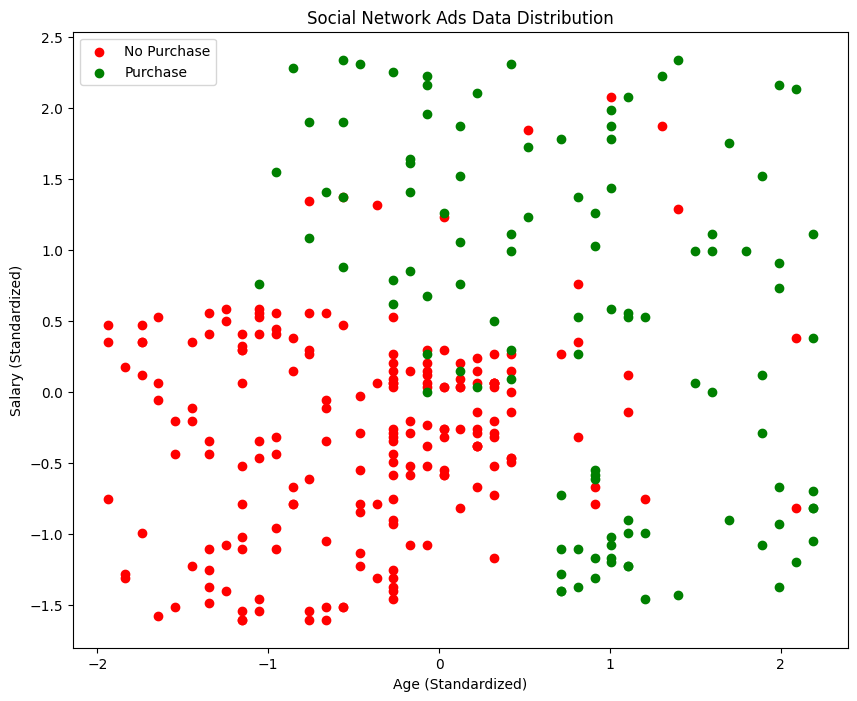

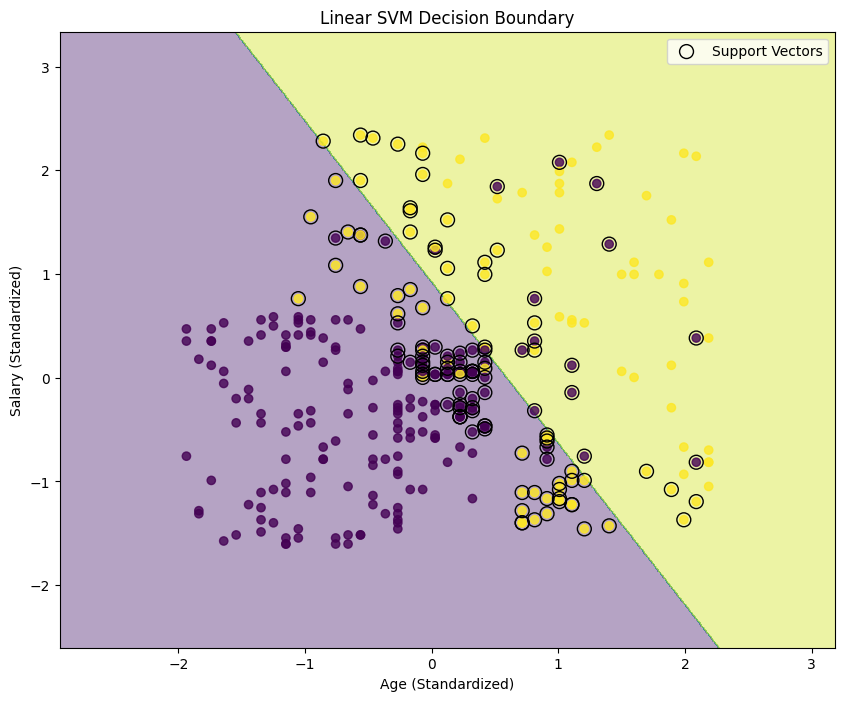

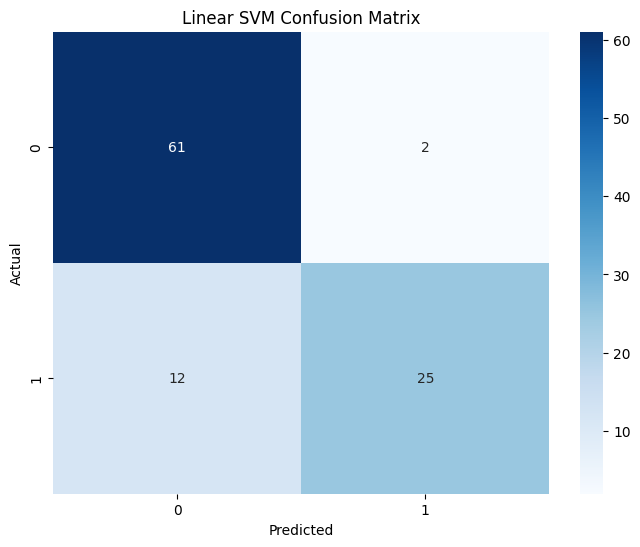

Linear SVM Accuracy: 0.8600


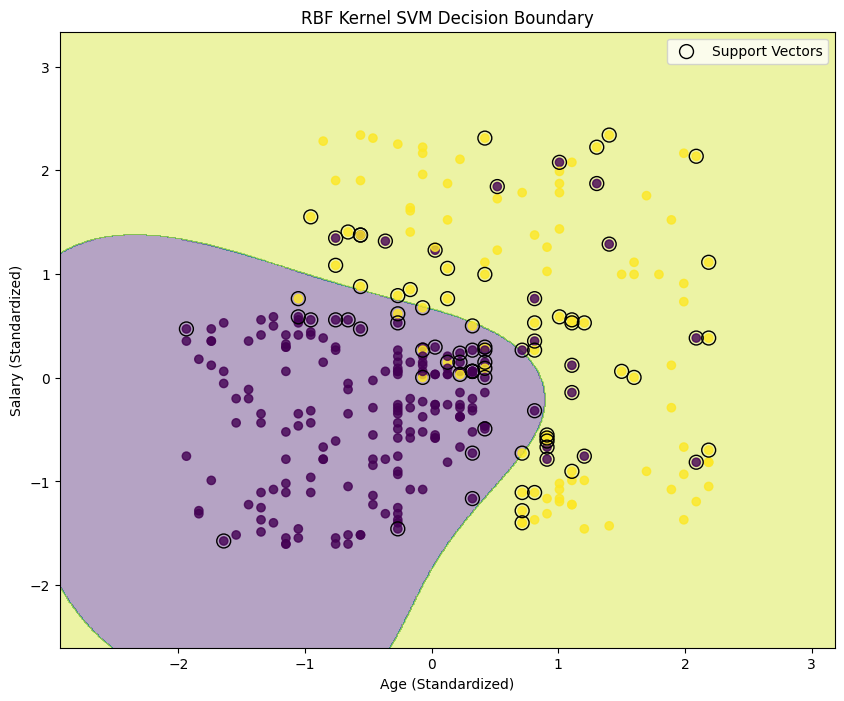

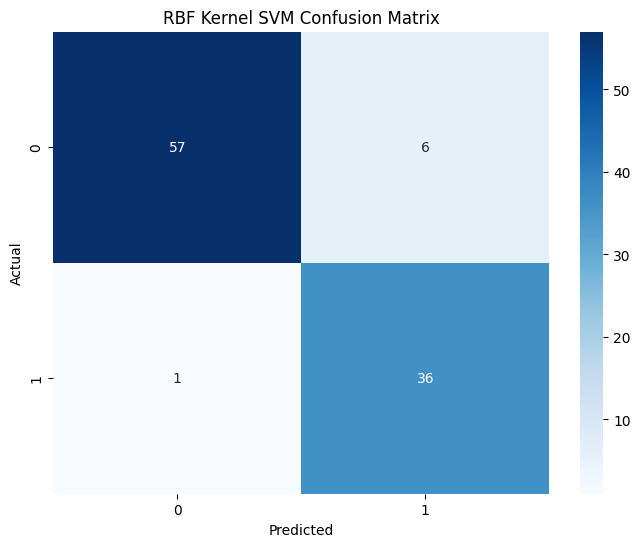

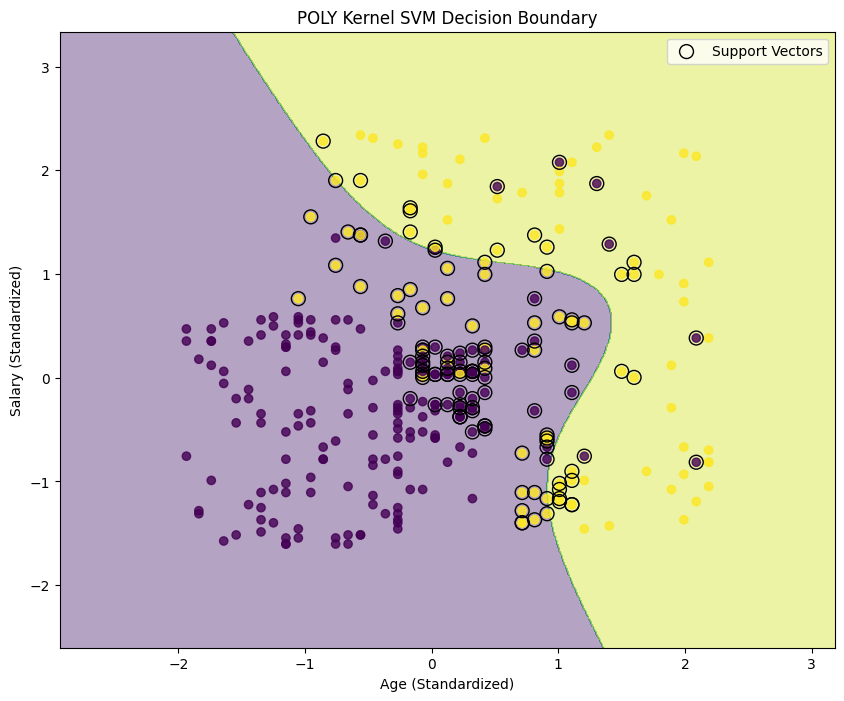

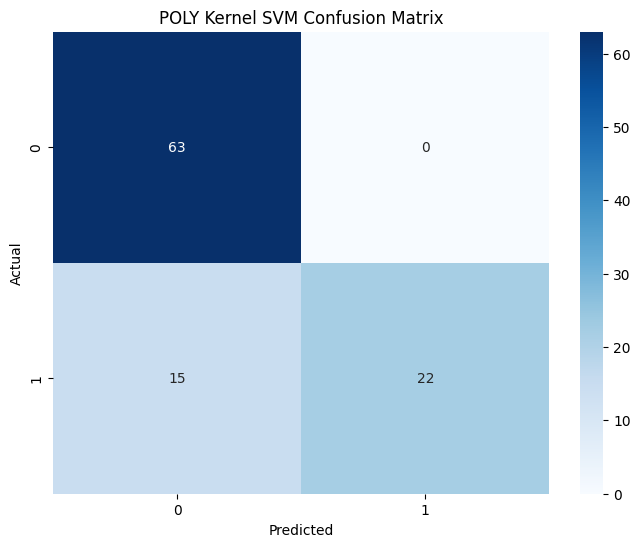

RBF Kernel SVM Accuracy: 0.9300
POLY Kernel SVM Accuracy: 0.8500


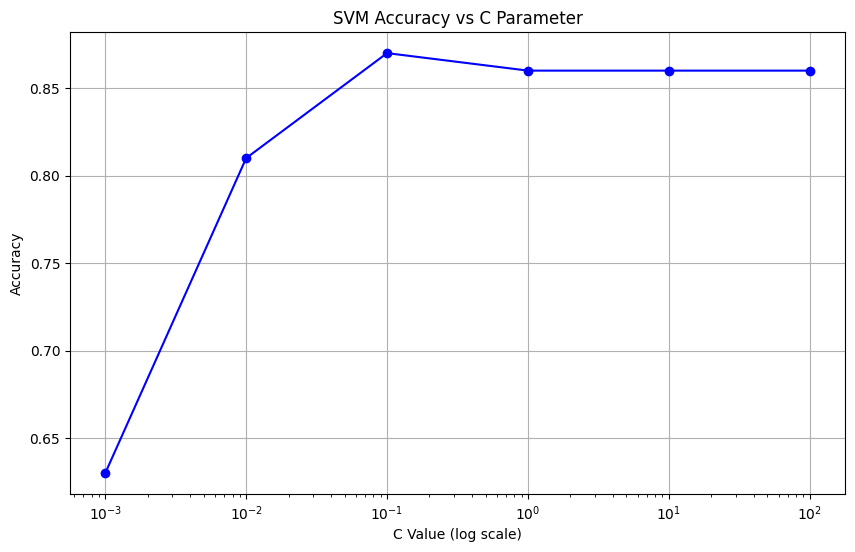


Accuracy for different C values:
C=0.001: 0.6300
C=0.01: 0.8100
C=0.1: 0.8700
C=1: 0.8600
C=10: 0.8600
C=100: 0.8600


In [7]:
# Main execution
if __name__ == "__main__":
    # Load and prepare data
    X_train, X_test, y_train, y_test, sc = load_and_prepare_data()

    # Question 1: Visualize data
    visualize_raw_data(X_train, y_train)

    # Question 2 & 3: Linear SVM
    linear_svm, linear_acc = linear_svm_analysis(X_train, X_test, y_train, y_test)
    print(f"Linear SVM Accuracy: {linear_acc:.4f}")

    # Question 4: Kernel SVM
    kernel_results = kernel_svm_analysis(X_train, X_test, y_train, y_test)
    for kernel, acc in kernel_results.items():
        print(f"{kernel.upper()} Kernel SVM Accuracy: {acc:.4f}")

    # Question 6: C parameter analysis
    c_results = c_parameter_analysis(X_train, X_test, y_train, y_test)
    print("\nAccuracy for different C values:")
    for c, acc in c_results.items():
        print(f"C={c}: {acc:.4f}")